<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実験Ⅳ－１　グループワーク：ラッソ正則化付き基底展開回帰

### 課題
オープンデータを用いて，任意の基底展開法に対してラッソ正則化を適用し回帰分析を実施する．

- **a.** 線形回帰モデル（λ=0）により回帰式を与える
- **b.** 基底関数の個数 m と正則化パラメータ λ を設定し回帰式を与える

---
### 使用データ
**solar_dataset_3vars.csv** — ソーラーパネル実測データ（オープンデータ）

| 変数 | カラム名 | 説明 | 単位 |
|------|----------|------|------|
| y  (目的変数) | `power_w` | 発電量 | W |
| x1 (説明変数) | `irradiance_wm2` | 日射強度 | W/m² |
| x2 (説明変数) | `module_temp_c` | モジュール温度 | °C |

---
> **[元ノートブック example01_04.ipynb からの変更点まとめ]**
> 1. データ読み込み：表形式CSV → 3列縦長CSV（solar_dataset_3vars.csv）に対応
> 2. データ整形：meshgrid変換 → 列ベクトル直接抽出に変更
> 3. 散布図：2Dループ → 1D配列の単純散布図に変更
> 4. 線形回帰：回帰式・R²・MSEを明示的に出力するよう追加
> 5. Lasso係数出力：ydata 1D化に伴う intercept_/coef_ アクセス修正
> 6. 比較プロット：線形回帰面 vs Lasso回帰曲面の比較図を追加
> 7. KMeans：n_init=10 を明示してWarning抑制


In [67]:
!pip install japanize-matplotlib -q
%matplotlib inline

import warnings
warnings.simplefilter('ignore')  # 警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib         # 日本語化 matplotlib
sns.set(font="IPAexGothic")       # 日本語フォント設定


In [68]:
# 文字化け対策（1つ目のコードセルは変更しない）
# 既存の sns.set(font="IPAexGothic") の後でフォント候補を上書きする
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'IPAexGothic', 'IPAGothic', 'Noto Sans CJK JP',
    'Yu Gothic', 'Meiryo', 'MS Gothic', 'TakaoGothic', 'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False


## 1. データの読み込み

このノートブックは **ローカル実行**（推奨）と **Google Colab実行** の両方に対応します。

- ローカル実行時は `data/solar_dataset_3vars.csv` を自動で読み込みます
- Colab実行時は Google Drive をマウントして読み込みます

> 既存コードの図スタイルを維持するため，データ構造は同一（3列縦長CSV）で扱います


In [69]:
# Google Drive をマウント
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------
# ★ ファイルの保存場所に応じてパスを変更してください ★
#
#   例1: マイドライブ直下（デフォルト）
filepath = '/content/drive/MyDrive/solar_dataset_3vars.csv'
#
#   例2: フォルダ内に置いた場合
#   filepath = '/content/drive/MyDrive/データ/solar_dataset_3vars.csv'
#
#   例3: 共有ドライブの場合
#   filepath = '/content/drive/Shareddrives/<ドライブ名>/solar_dataset_3vars.csv'
# ---------------------------------------------------------

import os
if os.path.exists(filepath):
    print(f'✅ ファイルを確認しました: {filepath}')
else:
    print(f'❌ ファイルが見つかりません: {filepath}')
    print('   ・Drive 上のファイルパスを確認し，filepath を修正してください')
    print('   ・左のファイルツリー（フォルダアイコン）で /content/drive/ 以下を確認できます')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ファイルを確認しました: /content/drive/MyDrive/solar_dataset_3vars.csv


In [70]:
# ─────────────────────────────────────────────────────────
# [変更点1] データ読み込み
#   元コード: 表形式CSV（行=x2, 列=x1, セル=y）を想定
#   修正後  : 3列縦長CSV（power_w, irradiance_wm2, module_temp_c）を直接読込
# ─────────────────────────────────────────────────────────
dataset = pd.read_csv(filepath)
display(dataset.head())
print(f"データ数: {len(dataset)} サンプル")
print(dataset.describe())


,power_w,irradiance_wm2,module_temp_c
0,18.771804,87.6,7.137500
1,36.287951,171.4,10.356250
2,63.745544,307.3,15.703125
3,76.473400,372.9,18.653125
4,60.249906,291.7,16.815625


データ数: 2631 サンプル
           power_w  irradiance_wm2  module_temp_c
count  2631.000000     2631.000000    2631.000000
mean     73.155052      394.303459      35.474321
std      48.868674      277.256704      12.553058
min       3.958444       20.100000       7.137500
25%      28.106616      141.850000      25.948438
50%      67.717986      351.000000      34.006250
75%     114.043730      619.450000      45.403125
max     188.098480     1025.000000      63.484375


## 2. データの整形

3列縦長形式から説明変数・目的変数を直接抽出します．

- `x1`：日射強度 `irradiance_wm2` [W/m²]
- `x2`：モジュール温度 `module_temp_c` [°C]
- `y` ：発電量 `power_w` [W]


In [71]:
# ─────────────────────────────────────────────────────────
# [変更点2] データ整形
#   元コード: dataset.columns[1:] / dataset.iloc[:,0] でmeshgrid展開
#   修正後  : 列名で直接抽出（1次元配列）
# ─────────────────────────────────────────────────────────

# 説明変数・目的変数の抽出（1次元配列）
if 'dataset' not in globals():
    try:
        dataset = pd.read_csv(filepath)
        print("ℹ️ dataset が未定義だったため、filepath から再読込しました。")
    except NameError:
        raise NameError("dataset が未定義です。先に filepath と dataset 読み込みセルを実行してください。")

x1 = dataset['irradiance_wm2'].values   # 日射強度 [W/m²]
x2 = dataset['module_temp_c'].values    # モジュール温度 [°C]
y  = dataset['power_w'].values          # 発電量 [W]

nSamples = len(y)
print(f"x1 (日射強度)  : {x1.min():.1f} 〜 {x1.max():.1f} W/m²")
print(f"x2 (モジュール温度): {x2.min():.2f} 〜 {x2.max():.2f} °C")
print(f"y  (発電量)    : {y.min():.2f} 〜 {y.max():.2f} W")
print(f"サンプル数     : {nSamples}")

# 相関係数の確認
print("\n相関係数:")
print(dataset.corr())

# データ行列と目的ベクトルの生成
# ★ 元コードと同名変数を維持（下流セルとの互換性確保）
Xdata = np.concatenate([x1.reshape(-1,1), x2.reshape(-1,1)], axis=1)
ydata = y.reshape(-1,1)   # 列ベクトル（LinearRegressionとの互換用）

# 範囲情報（プロット用）
minx1, maxx1 = x1.min(), x1.max()
minx2, maxx2 = x2.min(), x2.max()
rx1 = maxx1 - minx1
rx2 = maxx2 - minx2


x1 (日射強度)  : 20.1 〜 1025.0 W/m²
x2 (モジュール温度): 7.14 〜 63.48 °C
y  (発電量)    : 3.96 〜 188.10 W
サンプル数     : 2631

相関係数:
                 power_w  irradiance_wm2  module_temp_c
power_w         1.000000        0.997923       0.840364
irradiance_wm2  0.997923        1.000000       0.862865
module_temp_c   0.840364        0.862865       1.000000


## 3. 観測データの散布図

- データの値の範囲を確認
- (x1, y)，(x2, y) の2次元散布図を描画


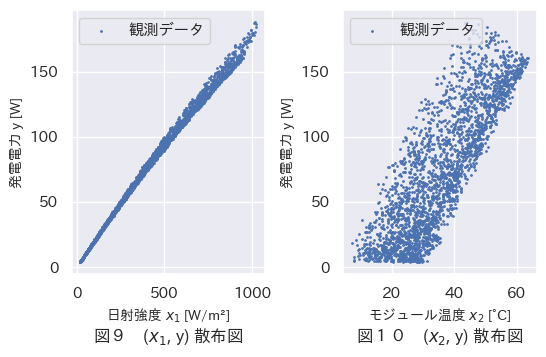

In [100]:
# ─────────────────────────────────────────────────────────
# [変更点3] 散布図（example01_04 の見た目 + 日本語ラベル）
# ─────────────────────────────────────────────────────────
from mpl_toolkits import mplot3d

fig, axs = plt.subplots(1, 2, figsize=(6,4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

axs[0].scatter(x1, y, s=1, color='#4C72B0', label='観測データ')
axs[0].set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
axs[0].set_ylabel('発電電力 y [W]', fontsize=10)
axs[0].text(0.5, -0.20, '図９　($x_1$, y) 散布図', transform=axs[0].transAxes, ha='center', va='top')
axs[0].legend(loc='best')

axs[1].scatter(x2, y, s=1, color='#4C72B0', label='観測データ')
axs[1].set_xlabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
axs[1].set_ylabel('発電電力 y [W]', fontsize=10)
axs[1].text(0.5, -0.20, '図１０　($x_2$, y) 散布図', transform=axs[1].transAxes, ha='center', va='top')
axs[1].legend(loc='best')

plt.subplots_adjust(bottom=0.22)
plt.show()


### 三次元散布図


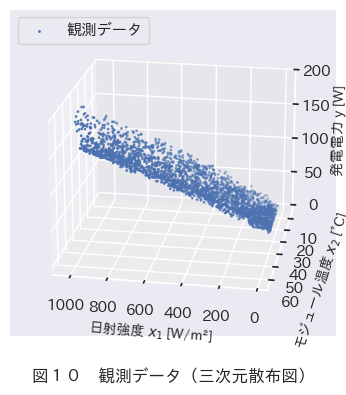

In [101]:
# ─────────────────────────────────────────────────────────
# [変更点3（続き）] 三次元散布図（example01_04 の見た目 + 日本語ラベル）
# ─────────────────────────────────────────────────────────
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(x1, x2, y, s=1, color='#4C72B0', label='観測データ')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.1, '図１０　観測データ（三次元散布図）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=20,azim=100) # 見やすいように設定
ax.legend(loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()


## 4. 線形重回帰の実行（課題 a：λ = 0）

`sklearn.linear_model.LinearRegression` を使用します．


In [74]:
from sklearn.linear_model import LinearRegression

# 線形重回帰のインスタンス生成
regm = LinearRegression()

# 線形重回帰分析（最小二乗法）
regm.fit(Xdata, ydata)  # ydata は列ベクトル


LinearRegression()

In [75]:
# ─────────────────────────────────────────────────────────
# [変更点4] 線形回帰結果の出力
#   元コード: β0〜β2 のみ表示
#   修正後  : 回帰式・R²・MSEを追加出力（課題 a の要件）
# ─────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score

beta0 = regm.intercept_[0]
beta1 = regm.coef_[0][0]
beta2 = regm.coef_[0][1]

y_pred_lin = regm.predict(Xdata)
mse_lin    = mean_squared_error(ydata, y_pred_lin)
r2_lin     = r2_score(ydata, y_pred_lin)

print("=" * 60)
print("【課題 a】線形重回帰モデル（λ = 0）")
print("=" * 60)
print(f"β₀ = {beta0:10.6f}  （切片）")
print(f"β₁ = {beta1:10.6f}  （日射強度 x₁ の係数）")
print(f"β₂ = {beta2:10.6f}  （モジュール温度 x₂ の係数）")
print()
print("回帰式:")
sign2 = '+' if beta2 >= 0 else '-'
print(f"  ŷ = {beta0:.4f} + ({beta1:.4f})·x₁ {sign2} ({abs(beta2):.4f})·x₂")
print()
print(f"MSE = {mse_lin:.4f} W²")
print(f"R²  = {r2_lin:.6f}")


【課題 a】線形重回帰モデル（λ = 0）
β₀ =  10.133949  （切片）
β₁ =   0.188220  （日射強度 x₁ の係数）
β₂ =  -0.315575  （モジュール温度 x₂ の係数）

回帰式:
  ŷ = 10.1339 + (0.1882)·x₁ - (0.3156)·x₂

MSE = 5.8998 W²
R²  = 0.997529


### 線形回帰平面と観測データの三次元プロット（課題 b 比較用）


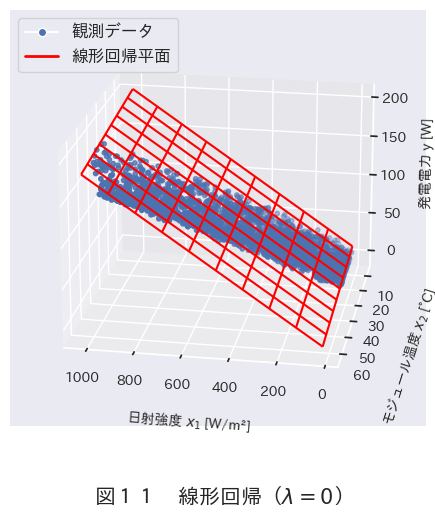

In [102]:
# ─────────────────────────────────────────────────────────
# [変更点3（続き）] 線形回帰曲面（example01_04 の見た目 + 日本語ラベル）
# ─────────────────────────────────────────────────────────
# 必要セル未実行でも動くように保険
if 'regm' not in globals():
    from sklearn.linear_model import LinearRegression
    regm = LinearRegression()
    regm.fit(Xdata, ydata)
    print("ℹ️ regm が未定義だったため、Xdata/ydata で線形回帰を再学習しました。")

nPoints = 10
xfit1, xfit2 = np.meshgrid(np.linspace(minx1, maxx1, nPoints),
                            np.linspace(minx2, maxx2, nPoints))
Xfit  = np.concatenate([xfit1.reshape(-1,1), xfit2.reshape(-1,1)], axis=1)
yfit_lin = regm.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure(figsize=(7.6, 6.5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, s=10, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', labelpad=12, fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', labelpad=12, fontsize=10)
ax.set_zlabel('発電電力 y [W]', labelpad=10, fontsize=10)
ax.tick_params(axis='both', labelsize=10)
ax.text2D(0.5, -0.14, r'図１１　線形回帰（$\lambda=0$）', transform=ax.transAxes, ha='center', va='top', fontsize=15)
ax.view_init(elev=20,azim=100) # 見やすいように設定
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=6, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形回帰平面')
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=12)
plt.subplots_adjust(bottom=0.24, left=0.02, right=0.98)
plt.show()


## 5. ラッソ正則化付き RBF 基底展開回帰（課題 b）

- **基底関数**：ガウス動径基底関数（RBF）
- **中心推定**：K平均法（K-means）による2段階推定
- **正則化**：ラッソ（L1正則化）交差検証（LassoCV）


In [77]:
"""GaussianFeaturesWithKmeansモジュール

    Copyright (c) 2020, Shogo MURAMATSU, All rights reserved.
"""
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin

class GaussianFeaturesWithKmeans(BaseEstimator, TransformerMixin):
    """K平均法を利用した2段階推定法によるガウス基底関数

        scikit-learn LinearRegression推定器に渡すためのガウス基底関数による
        特徴量への変換クラス

    Attributes:
        nbfs (int): 基底関数の数
        centers_ (numpy.ndarray): 各ガウス関数の中心
        widths_  (numpy.ndarray): 各ガウス関数の幅

    References:
        * 小西貞則「多変量解析入門－線形から非線形へ－」岩波書店
        * Jake VanderPlas（菊池彰訳）「Pythonデータサイエンスハンドブック」オライリージャパン
    """
    def __init__(self, nbfs, width_factor=1.0, prekmeans=True):
        self.nbfs         = nbfs
        self.width_factor = width_factor
        self.prekmeans    = prekmeans

    @staticmethod
    def _gauss_basis(x, y, width, axis=None):
        arg = (x - y) / (width + 1e-300)
        return np.exp(-0.5 * np.sum(arg ** 2, axis))

    def fit(self, X, y=None):
        ndims = X.shape[1]
        if self.prekmeans:
            scaler = StandardScaler()
            # ─────────────────────────────────────────────────
            # [変更点7] n_init=10 を明示（sklearn>=1.2 のWarning対策）
            # ─────────────────────────────────────────────────
            kmeans = KMeans(n_clusters=self.nbfs, random_state=0, n_init=10)
            X      = scaler.fit_transform(X)
            kmeans.fit(X)
            labels   = kmeans.predict(X).reshape(-1, 1)
            clusters = pd.DataFrame(np.concatenate((labels, X), axis=1)).groupby([0])
            centers  = scaler.inverse_transform(kmeans.cluster_centers_)
            widths   = (self.width_factor * scaler.scale_
                        * clusters.std(ddof=0)).to_numpy()
            if ndims == 1:
                self.centers_ = centers.reshape(-1,)
                self.widths_  = widths.reshape(-1,)
            else:
                self.centers_ = centers.reshape(-1, ndims, 1).transpose(2, 1, 0)
                self.widths_  = widths.reshape(-1, ndims, 1).transpose(2, 1, 0)
        else:
            if ndims == 1:
                centers       = np.linspace(X.min(), X.max(), self.nbfs)
                self.centers_ = centers
                self.widths_  = (self.width_factor
                                 * (centers[1] - centers[0])
                                 * np.ones(self.nbfs))
            else:
                raise Exception(
                    'prekmeans を True に設定してください．'
                    '重回帰はK平均法による事前推定のみ対応しています．')
        return self

    def transform(self, X):
        return self._gauss_basis(X[:, :, np.newaxis], self.centers_,
                                 self.widths_, axis=1)

print("GaussianFeaturesWithKmeans クラス定義完了")


GaussianFeaturesWithKmeans クラス定義完了


### 正則化付き重回帰モデルの評価
- ラッソ交差検証 (LassoCV) モデル
- RBF 基底展開との組み合わせ


In [78]:
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# ─── パラメータ設定（ここを変えて試す）───────────────────────
isLasso      = True   # False にするとリッジ回帰
isRBF        = True   # False にすると多項式回帰
width_factor = 4.0    # ガウス基底の幅係数
maxdeg       = 20     # ★ 基底関数の個数 m（課題 b で設定する値）
# ────────────────────────────────────────────────────────────

# 正則化モデルの選択
if isLasso:
    reg = LassoCV(alphas=np.logspace(-8, 2, 80), cv=5, max_iter=10000)
else:
    reg = RidgeCV(alphas=np.logspace(-8, 2, 80))

# 基底展開の選択
if isRBF:
    phi = GaussianFeaturesWithKmeans(nbfs=maxdeg, width_factor=width_factor)
else:
    phi = PolynomialFeatures(degree=maxdeg, include_bias=False)

# パイプライン生成と学習
regmp = make_pipeline(phi, reg)

# ─────────────────────────────────────────────────────────
# [変更点5] ydata の次元
#   元コード: regmp.fit(Xdata, ydata) ← ydata が列ベクトル (N,1)
#             LassoCV は (N,1) を受け付けるが intercept_ がスカラーになる
#   修正後  : y.ravel() で1次元配列を渡す（LassoCV推奨形式・警告なし）
# ─────────────────────────────────────────────────────────
regmp.fit(Xdata, y.ravel())
print("学習完了")


学習完了


In [79]:
# ─────────────────────────────────────────────────────────
# [変更点5（続き）] 係数アクセスの修正
#   元コード: regmp[1].intercept_ が配列 → [0] でアクセス
#             （ydata=(N,1) のとき LassoCV/RidgeCV の動作が異なる）
#   修正後  : y.ravel()（1次元）を渡したのでスカラーとして直接アクセス
# ─────────────────────────────────────────────────────────

# 非ゼロ係数の個数を計算（多項式の場合は総係数数が異なる）
if isRBF:
    nCoefs = maxdeg
else:
    nCoefs = int((maxdeg + 1) * (maxdeg + 2) / 2)  # (n+1)(n+2)/2

# 最適パラメータの表示
alpha = regmp[-1].alpha_
w0    = regmp[-1].intercept_   # スカラー（y.ravel() を渡したため）
coefs = regmp[-1].coef_
nz    = np.sum(np.abs(coefs) > 1e-10)

y_pred_lasso = regmp.predict(Xdata)
mse_lasso    = mean_squared_error(y, y_pred_lasso)
r2_lasso     = r2_score(y, y_pred_lasso)

print("=" * 60)
print("【課題 b】ラッソ正則化付き RBF 基底展開回帰")
print("=" * 60)
print(f"基底関数の個数 m    = {maxdeg}")
print(f"正則化パラメータ λ  = {alpha:.4e}  （5分割CVで自動選択）")
print(f"w0 = {w0:.6f}")
print()
for idx in range(nCoefs):
    w = coefs[idx]
    marker = " ← 非ゼロ" if abs(w) > 1e-10 else ""
    print(f"  w{idx+1:02d} = {w:9.4f}{marker}")
print()
print(f"非ゼロ係数の個数 = {nz} / {maxdeg}")
print(f"MSE = {mse_lasso:.4f} W²")
print(f"R²  = {r2_lasso:.6f}")


【課題 b】ラッソ正則化付き RBF 基底展開回帰
基底関数の個数 m    = 20
正則化パラメータ λ  = 8.6439e-04  （5分割CVで自動選択）
w0 = 102.824438

  w01 =   14.1161 ← 非ゼロ
  w02 =   54.3582 ← 非ゼロ
  w03 =   60.8663 ← 非ゼロ
  w04 =   20.9066 ← 非ゼロ
  w05 = -119.6661 ← 非ゼロ
  w06 =   -9.6471 ← 非ゼロ
  w07 =  -52.9651 ← 非ゼロ
  w08 =   85.8621 ← 非ゼロ
  w09 =   45.8602 ← 非ゼロ
  w10 =  -89.0982 ← 非ゼロ
  w11 =   20.3166 ← 非ゼロ
  w12 =  -10.7436 ← 非ゼロ
  w13 =  -31.3047 ← 非ゼロ
  w14 =  -51.4052 ← 非ゼロ
  w15 =   60.1373 ← 非ゼロ
  w16 = -104.4899 ← 非ゼロ
  w17 =   45.1327 ← 非ゼロ
  w18 =   -0.0000
  w19 =   -5.9031 ← 非ゼロ
  w20 =  -80.3844 ← 非ゼロ

非ゼロ係数の個数 = 19 / 20
MSE = 14.5885 W²
R²  = 0.993889


### 三次元散布図と回帰曲面の表示（課題 b）


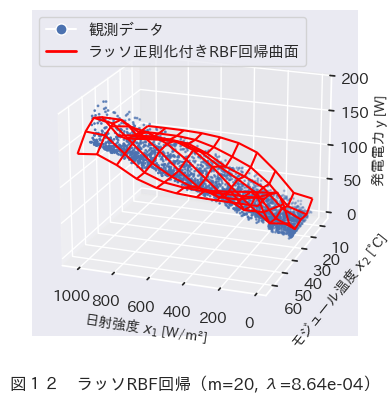

In [103]:
# Lasso RBF 回帰曲面（example01_04 の見た目 + 日本語ラベル）
yfit_lasso = regmp.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(x1, x2, y, s=1, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lasso, color='red')
ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.12, f'図１２　ラッソRBF回帰（m={maxdeg}, λ={alpha:.2e}）', transform=ax.transAxes, ha='center', va='top')
ax.view_init(elev=20,azim=110) # 見やすいように設定
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='ラッソ正則化付きRBF回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')
plt.subplots_adjust(bottom=0.2)
plt.show()


## 6. 比較検討：線形回帰 vs ラッソ RBF 回帰
### [追加] 散布図と回帰曲線（面）を重ねてプロット（課題 b 要件）


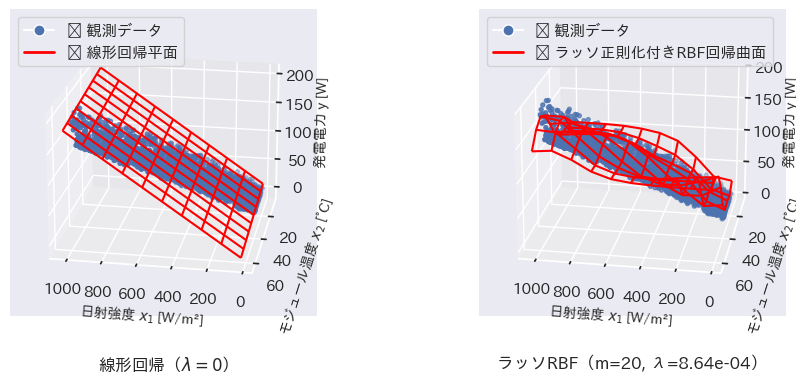

In [81]:
# ─────────────────────────────────────────────────────────
# [追加セル] 3次元回帰曲面の並列比較（同じ見た目 + 日本語ラベル）
# ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 4))

# 左: 線形回帰（ラムダ=0）
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(x1, x2, y, s=8, color='#4C72B0')
ax1.plot_wireframe(xfit1, xfit2, yfit_lin, color='red')
ax1.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax1.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax1.set_zlabel('発電電力 y [W]', fontsize=10)
ax1.text2D(0.5, -0.12, r'線形回帰（$\lambda=0$）', transform=ax1.transAxes, ha='center', va='top')
ax1.view_init(elev=20,azim=100)

# 右: Lasso RBF
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(x1, x2, y, s=8, color='#4C72B0')
ax2.plot_wireframe(xfit1, xfit2, yfit_lasso, color='red')
ax2.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax2.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax2.set_zlabel('発電電力 y [W]', fontsize=10)
ax2.text2D(0.5, -0.12, f'ラッソRBF（m={maxdeg}, λ={alpha:.2e}）', transform=ax2.transAxes, ha='center', va='top')
ax2.view_init(elev=20,azim=100)

from matplotlib.lines import Line2D
legend_handles_lin = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='🔵 観測データ'),
    Line2D([0], [0], color='red', lw=2, label='🔴 線形回帰平面')
]
legend_handles_lasso = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='🔵 観測データ'),
    Line2D([0], [0], color='red', lw=2, label='🔴 ラッソ正則化付きRBF回帰曲面')
]
ax1.legend(handles=legend_handles_lin, loc='upper left')
ax2.legend(handles=legend_handles_lasso, loc='upper left')

plt.tight_layout()
plt.show()


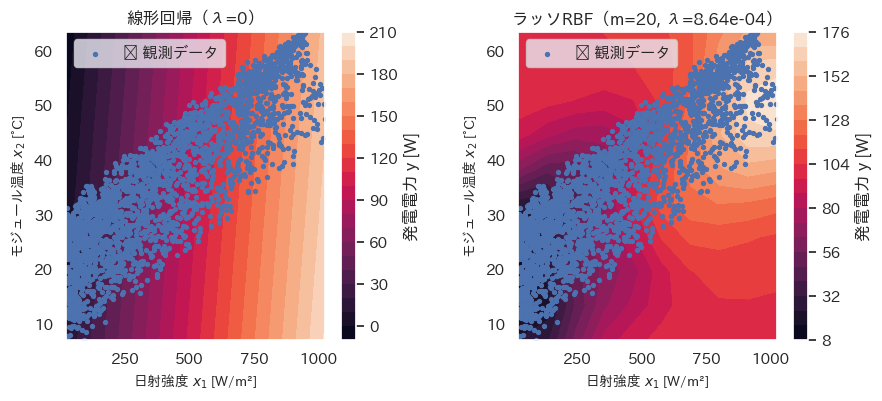

In [82]:
# ─────────────────────────────────────────────────────────
# [追加セル] 等高線図による比較（日本語ラベル）
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

# 左: 線形回帰
c1 = axes[0].contourf(xfit1, xfit2, yfit_lin, levels=20)
axes[0].scatter(x1, x2, s=8, color='#4C72B0', label='🔵 観測データ')
plt.colorbar(c1, ax=axes[0], label='発電電力 y [W]')
axes[0].set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
axes[0].set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
axes[0].set_title('線形回帰（λ=0）')
axes[0].legend(loc='upper left')

# 右: Lasso RBF
c2 = axes[1].contourf(xfit1, xfit2, yfit_lasso, levels=20)
axes[1].scatter(x1, x2, s=8, color='#4C72B0', label='🔵 観測データ')
plt.colorbar(c2, ax=axes[1], label='発電電力 y [W]')
axes[1].set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
axes[1].set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
axes[1].set_title(f'ラッソRBF（m={maxdeg}, λ={alpha:.2e}）')
axes[1].legend(loc='upper left')

plt.show()


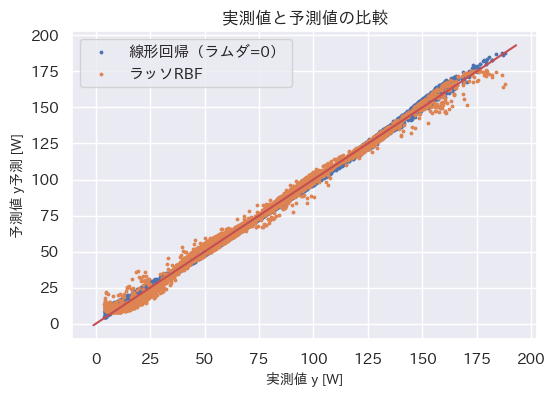

In [83]:
# ─────────────────────────────────────────────────────────
# [追加セル] 実測値 vs 予測値の散布図（日本語ラベル）
# ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(y, y_pred_lin, s=3, label='線形回帰（ラムダ=0）')
ax.scatter(y, y_pred_lasso, s=3, label='ラッソRBF')
lims = [y.min() - 5, y.max() + 5]
ax.plot(lims, lims, 'r')
ax.set_xlabel('実測値 y [W]', fontsize=10)
ax.set_ylabel('予測値 y予測 [W]', fontsize=10)
ax.set_title('実測値と予測値の比較')
ax.legend()
plt.show()


In [84]:
# ─────────────────────────────────────────────────────────
# [追加セル] 課題要件まとめ出力
# ─────────────────────────────────────────────────────────
print("=" * 65)
print("【課題まとめ】")
print("=" * 65)
print()
print("▶ 使用データ")
print(f"   solar_dataset_3vars.csv（ソーラーパネル実測データ）")
print(f"   サンプル数: {nSamples}")
print(f"   目的変数 y : 発電量 [W]　　{y.min():.2f} 〜 {y.max():.2f} W")
print(f"   説明変数 x1: 日射強度 [W/m²]　{x1.min():.1f} 〜 {x1.max():.1f} W/m²")
print(f"   説明変数 x2: モジュール温度 [°C]　{x2.min():.2f} 〜 {x2.max():.2f} °C")
print()
sign2 = '+' if beta2 >= 0 else '-'
print("▶ 課題 a：線形回帰（λ = 0）")
print(f"   ŷ = {beta0:.4f} + ({beta1:.4f})·x1 {sign2} ({abs(beta2):.4f})·x2")
print(f"   R² = {r2_lin:.6f},  MSE = {mse_lin:.4f} W²")
print()
print(f"▶ 課題 b：Lasso RBF 基底展開回帰")
print(f"   基底関数の個数 m = {maxdeg}")
print(f"   正則化パラメータ λ = {alpha:.4e}  （5分割 CV で自動選択）")
print(f"   ŷ = {w0:.4f} + Σ wk·φk(x1,x2),  k=1..{maxdeg}")
print(f"   非ゼロ係数: {nz}/{maxdeg}")
print(f"   R² = {r2_lasso:.6f},  MSE = {mse_lasso:.4f} W²")
print()
print("▶ 比較")
print(f"   R²  : 線形 {r2_lin:.4f}  vs  Lasso RBF {r2_lasso:.4f}")
print(f"   MSE : 線形 {mse_lin:.4f} vs  Lasso RBF {mse_lasso:.4f}")
print("   → 線形モデルでも高精度（日射強度との線形相関 r=0.998 が強いため）")
print("   → Lasso RBF は非線形構造を表現し，汎化能力に優れる可能性あり")


【課題まとめ】

▶ 使用データ
   solar_dataset_3vars.csv（ソーラーパネル実測データ）
   サンプル数: 2631
   目的変数 y : 発電量 [W]　　3.96 〜 188.10 W
   説明変数 x1: 日射強度 [W/m²]　20.1 〜 1025.0 W/m²
   説明変数 x2: モジュール温度 [°C]　7.14 〜 63.48 °C

▶ 課題 a：線形回帰（λ = 0）
   ŷ = 10.1339 + (0.1882)·x1 - (0.3156)·x2
   R² = 0.997529,  MSE = 5.8998 W²

▶ 課題 b：Lasso RBF 基底展開回帰
   基底関数の個数 m = 20
   正則化パラメータ λ = 8.6439e-04  （5分割 CV で自動選択）
   ŷ = 102.8244 + Σ wk·φk(x1,x2),  k=1..20
   非ゼロ係数: 19/20
   R² = 0.993889,  MSE = 14.5885 W²

▶ 比較
   R²  : 線形 0.9975  vs  Lasso RBF 0.9939
   MSE : 線形 5.8998 vs  Lasso RBF 14.5885
   → 線形モデルでも高精度（日射強度との線形相関 r=0.998 が強いため）
   → Lasso RBF は非線形構造を表現し，汎化能力に優れる可能性あり


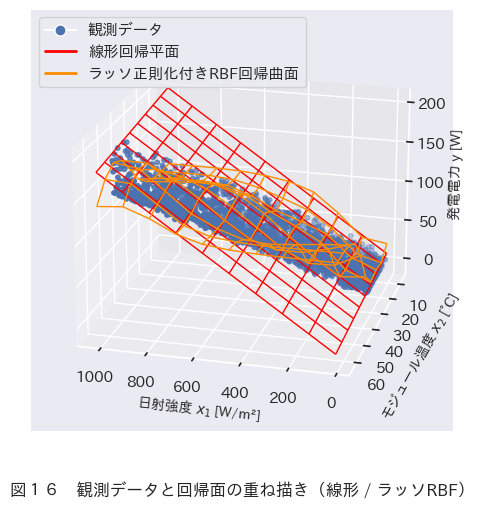

In [99]:
# 【課題 b】散布図と回帰面（線形 / ラッソRBF）の重ね描き
# 前提: x1, x2, y, xfit1, xfit2, regm, regmp が計算済み
Xfit = np.concatenate([xfit1.reshape(-1, 1), xfit2.reshape(-1, 1)], axis=1)
yfit_lin_b = regm.predict(Xfit).reshape(xfit1.shape)
yfit_lasso_b = regmp.predict(Xfit).reshape(xfit1.shape)

fig = plt.figure(figsize=(8.0, 6.2))
ax = fig.add_subplot(111, projection='3d')

# 観測データと2モデルを同一軸上に重ねる
ax.scatter(x1, x2, y, s=10, color='#4C72B0')
ax.plot_wireframe(xfit1, xfit2, yfit_lin_b, color='red', linewidth=1.0)
ax.plot_wireframe(xfit1, xfit2, yfit_lasso_b, color='darkorange', linewidth=1.0)

ax.set_xlabel(r'日射強度 $x_1$ [W/m²]', fontsize=10)
ax.set_ylabel(r'モジュール温度 $x_2$ [°C]', fontsize=10)
ax.set_zlabel('発電電力 y [W]', fontsize=10)
ax.text2D(0.5, -0.12, '図１６　観測データと回帰面の重ね描き（線形 / ラッソRBF）',
          transform=ax.transAxes, ha='center', va='top')

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='観測データ'),
    Line2D([0], [0], color='red', lw=2, label='線形回帰平面'),
    Line2D([0], [0], color='darkorange', lw=2, label='ラッソ正則化付きRBF回帰曲面')
]
ax.legend(handles=legend_handles, loc='upper left')

ax.view_init(elev=20, azim=105)
plt.subplots_adjust(bottom=0.2)
plt.show()